# Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)

import pickle

import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [3]:
df = pd.read_csv("single_genre_artists.csv")

df.head()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


In [4]:
df.shape

(95837, 23)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  object 
 1   name_song           95837 non-null  object 
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  object 
 6   release_date        95837 non-null  object 
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  vale

# Checking missing values

In [6]:
df.isnull().sum()

id_songs              0
name_song             0
popularity_songs      0
duration_ms           0
explicit              0
id_artists            0
release_date          0
danceability          0
energy                0
key                   0
loudness              0
mode                  0
speechiness           0
acousticness          0
instrumentalness      0
liveness              0
valence               0
tempo                 0
time_signature        0
followers             0
genres                0
name_artists          0
popularity_artists    0
dtype: int64

# Checking Duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

# Select Features

In [8]:
features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms'
]

songs_df = df.copy()

# Distribution Plots

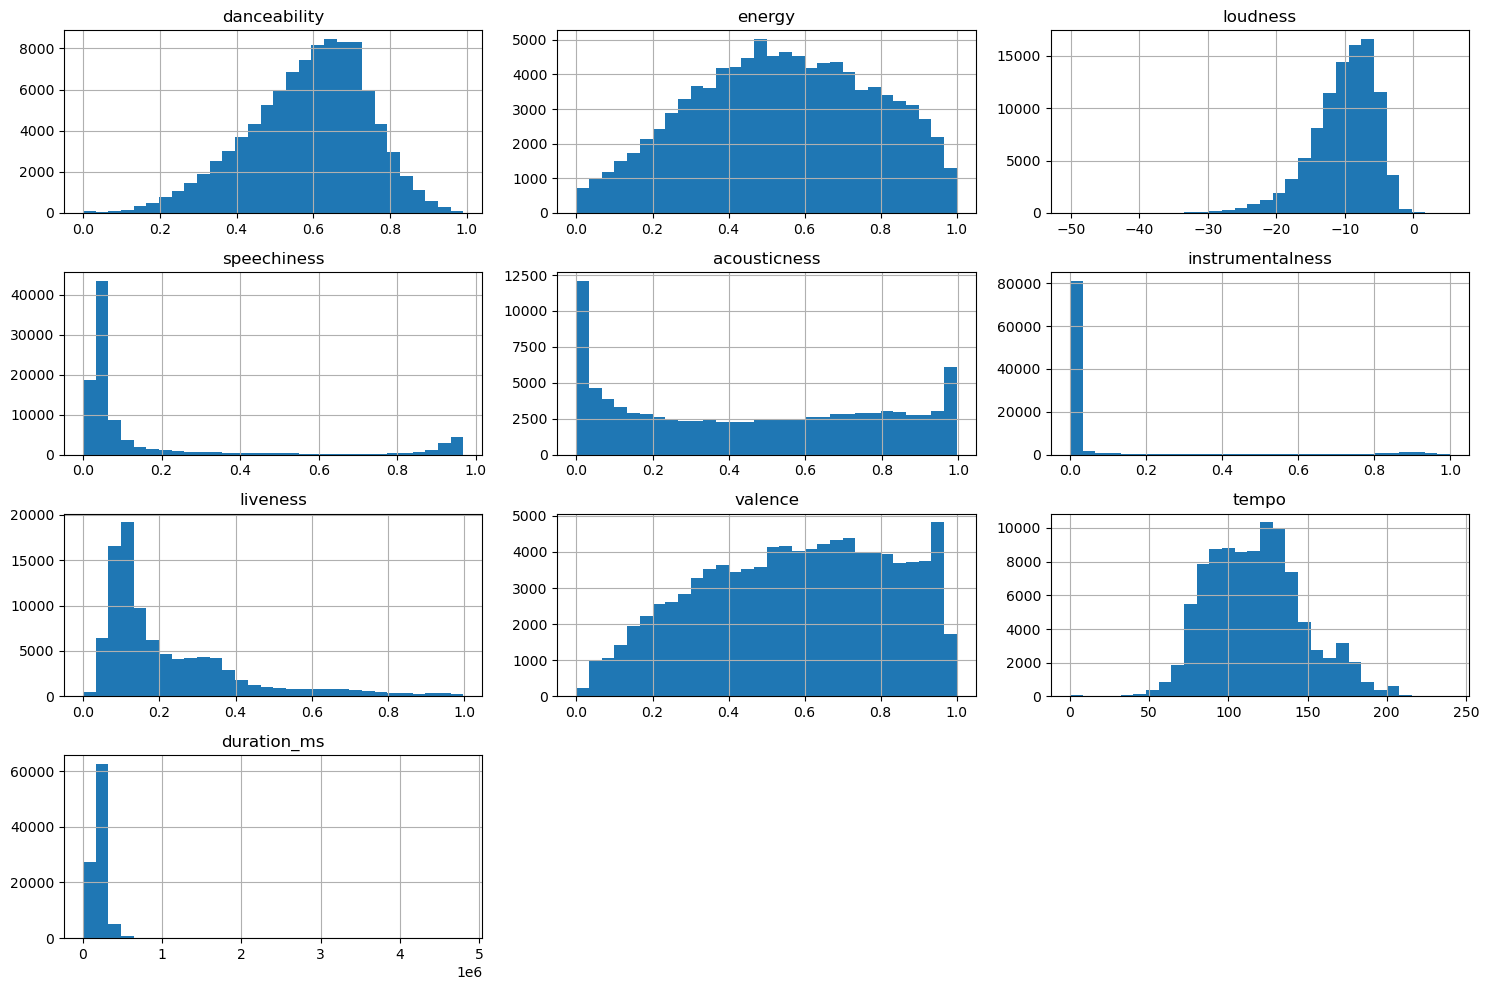

In [9]:
songs_df[features].hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

# Correlation Heatmap

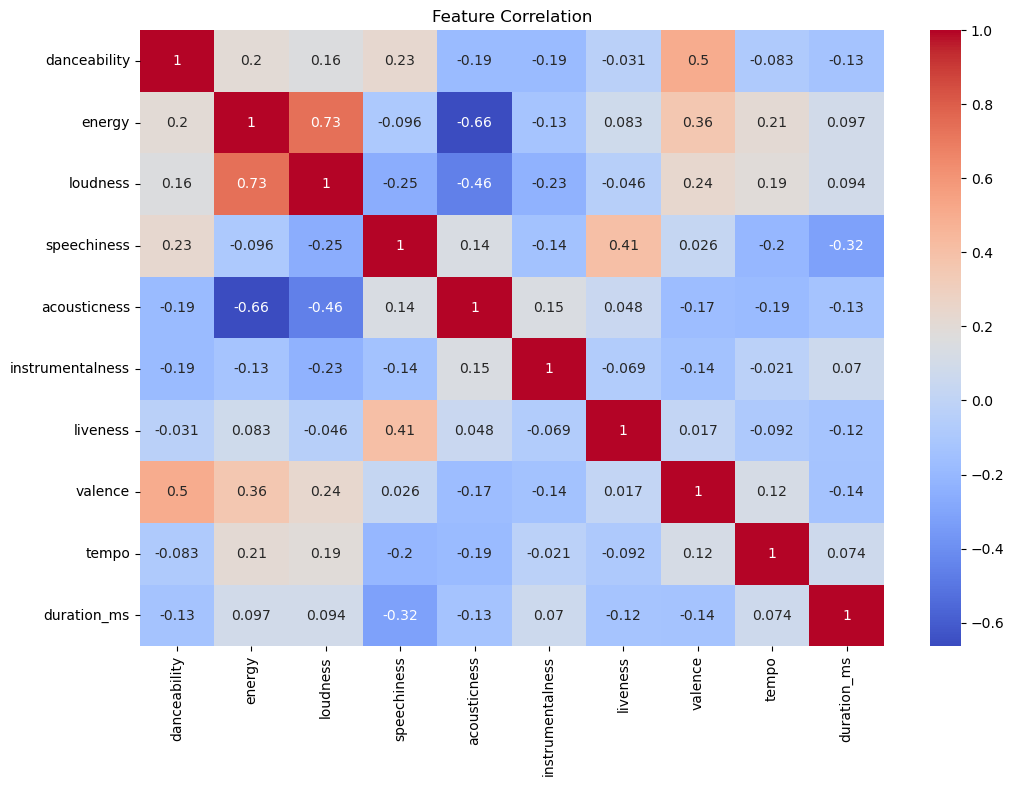

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    songs_df[features].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation")
plt.show()

# Feature Scaling

In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    songs_df[features]
)

X_scaled.shape

(95837, 10)

# Elbow Method

In [12]:
inertia = []

for k in range(2,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

# Elbow Plot

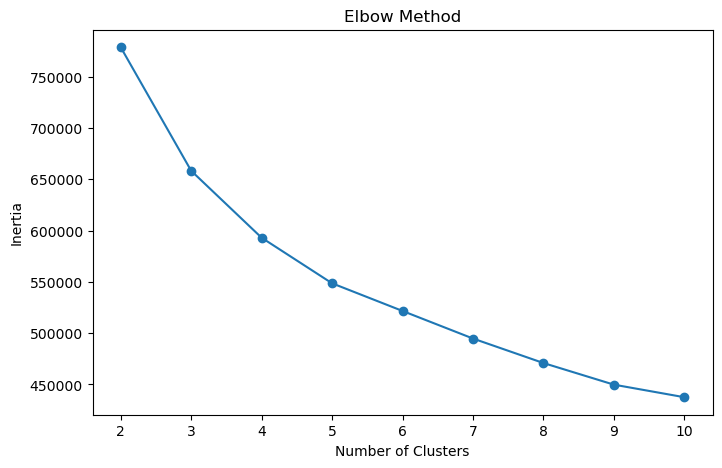

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

# Silhouette Scores

In [15]:
for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels,
        sample_size=10000,
        random_state=42
    )

    print(f"K={k}: {score:.4f}")

K=2: 0.1998
K=3: 0.2378
K=4: 0.2273
K=5: 0.1857
K=6: 0.1872
K=7: 0.1648
K=8: 0.1721
K=9: 0.1726
K=10: 0.1579


# Final KMeans

In [16]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

songs_df['Cluster'] = kmeans.fit_predict(
    X_scaled
)

# Cluster Counts

In [17]:
songs_df['Cluster'].value_counts()

Cluster
1    30223
3    24587
4    21215
2    12271
0     7541
Name: count, dtype: int64

# Silhouette Score

In [18]:
silhouette = silhouette_score(
    X_scaled,
    songs_df['Cluster']
)

print("Silhouette Score :", silhouette)

Silhouette Score : 0.18596876980108912


# Davies Bouldin Score

In [19]:
db_score = davies_bouldin_score(
    X_scaled,
    songs_df['Cluster']
)

print("Davies-Bouldin Score :", db_score)

Davies-Bouldin Score : 1.6886165062636276


# PCA

In [20]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(
    X_scaled
)

songs_df['PCA1'] = X_pca[:,0]
songs_df['PCA2'] = X_pca[:,1]

# PCA Visualization

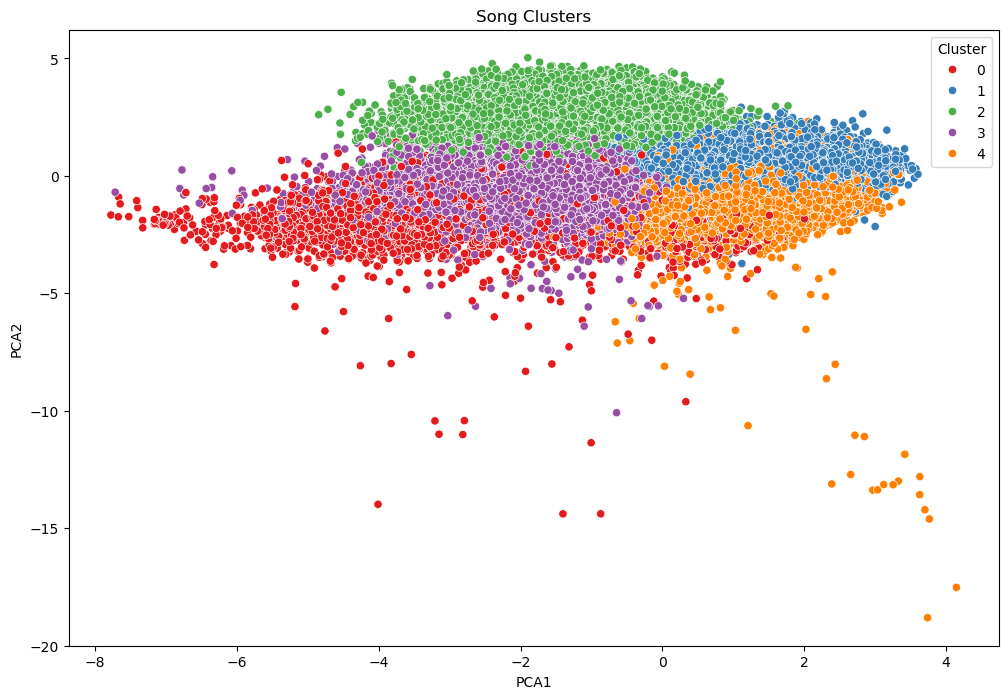

In [21]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=songs_df,
    palette='Set1'
)

plt.title("Song Clusters")
plt.show()

# Cluster Profiles

In [22]:
cluster_summary = songs_df.groupby(
    'Cluster'
)[features].mean()

cluster_summary

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
Cluster,,,,,,,,,,
0,0.484393,0.400734,-14.196592,0.059373,0.667338,0.817011,0.185205,0.449870,113.543365,227713.456836
1,0.707575,0.670385,-8.007445,0.078193,0.311642,0.021223,0.170715,0.787126,117.768624,213464.854846
2,0.664408,0.466415,-13.390332,0.839002,0.586284,0.000879,0.435679,0.583211,100.167455,96272.014017
3,0.503249,0.313795,-12.626270,0.062187,0.743109,0.018369,0.179686,0.418634,111.177219,221195.730223
4,0.503328,0.713370,-7.055322,0.072827,0.191931,0.028640,0.246758,0.490503,136.056928,245846.002640


# Cluster Heatmap

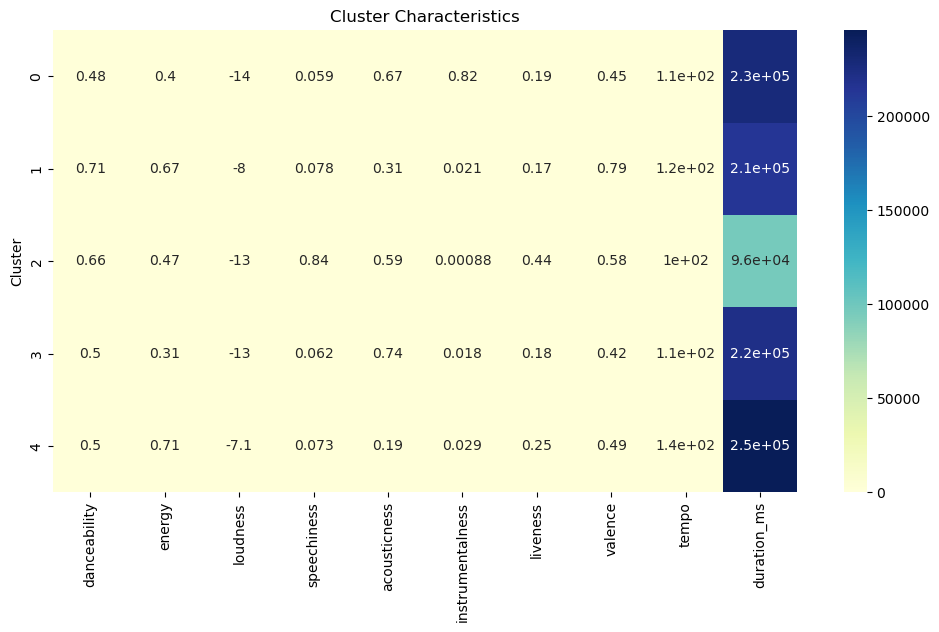

In [23]:
plt.figure(figsize=(12,6))

sns.heatmap(
    cluster_summary,
    annot=True,
    cmap='YlGnBu'
)

plt.title("Cluster Characteristics")

plt.show()

# Top songs per cluster

In [24]:
for cluster in sorted(
    songs_df['Cluster'].unique()
):

    print("\nCluster :", cluster)

    display(
        songs_df[
            songs_df['Cluster']==cluster
        ][[
            'name_song',
            'name_artists'
        ]].head(10)
    )


Cluster : 0


,name_song,name_artists
53,Veux Tu Que J'te Fasse Un Dessin,Georgius
65,West End Blues,Louis Armstrong & His Hot Five
67,Beau Koo Jack,Louis Armstrong & His Hot Five
69,Gut Bucket Blues,Louis Armstrong & His Hot Five
70,Skid-Dat-De-Dat,Louis Armstrong & His Hot Five
72,Skip The Gutter,Louis Armstrong & His Hot Five
74,Cornet Chop Suey,Louis Armstrong & His Hot Five
78,Savoy Blues,Louis Armstrong & His Hot Five
82,"Come Back, Sweet Papa",Louis Armstrong & His Hot Five
84,Who'sit,Louis Armstrong & His Hot Five



Cluster : 1


,name_song,name_artists
15,On M'suit,Mistinguett
34,Je N'suis Pas Celle Que Vous Croyez,Perchicot
38,La Noce À Rebecca,Perchicot
89,My Heart,Louis Armstrong & His Hot Five
103,Irish Black Bottom,Louis Armstrong & His Hot Five
105,Put 'Em Down Blues,Louis Armstrong & His Hot Five
115,Irish Black Bottom,Louis Armstrong & His Hot Five
116,My Heart,Louis Armstrong & His Hot Five
128,Hotter Than That,Louis Armstrong & His Hot Five
131,My Heart,Louis Armstrong & His Hot Five



Cluster : 2


,name_song,name_artists
37,Dites Moi Doumergue,Perchicot
43,Il N'osait Pas Se Decider,Georgius
50,L'amour Excuse Tout,Georgius
55,Le Genre De La Maison,Georgius
60,Oh Oh Il Travaille Du Chapeau,Georgius
63,C'est Jeune Et Ca N'sait Pas,Fortugé
104,Big Fat Ma and Skinny Pa,Louis Armstrong & His Hot Five
108,Big Fat Ma And Skinny Pa,Louis Armstrong & His Hot Five
146,A Monday Date,Louis Armstrong & His Hot Five
158,A Monday Date,Louis Armstrong & His Hot Five



Cluster : 3


,name_song,name_artists
0,La Java,Mistinguett
1,En Douce,Mistinguett
2,J'en Ai Marre,Mistinguett
3,Ils n'ont pas ca,Mistinguett
4,La belote,Mistinguett
5,Oh mademoiselle,Mistinguett
6,Il m'a vue nue,Mistinguett
7,Mon Bus'ness,Mistinguett
8,Ça c'est Paris,Mistinguett
9,Le Fado,Mistinguett



Cluster : 4


,name_song,name_artists
426,Hella Often Freestyle,Old Grape God
600,Ditty Diego,White Flag
601,100 Years from Now,White Flag
602,Jungle,White Flag
603,Don't Bring Me,White Flag
1010,La Canción del Ukelele - Remastered,Celia Gamez
1089,Ren og rettferdig,Stagedive Live
1150,Tsoupra to mantili sou,Roza Eskenazi
1363,Golfo,Giorgos Papasideris
1433,Are We Going Down,Why Not


# Saved model files

In [25]:
pickle.dump(
    scaler,
    open("scaler.pkl","wb")
)

pickle.dump(
    kmeans,
    open("kmeans_model.pkl","wb")
)

pickle.dump(
    pca,
    open("pca.pkl","wb")
)

# Export final dataset

In [26]:
songs_df.to_csv(
    "songs_clustered.csv",
    index=False
)

print("Exported Successfully")

Exported Successfully
